# **Античное наследие на карте современной Турции: карта греческих и римских исторических памятников**

Исследовательский вопрос:

Как распределены античные памятники на территории современной Турции, какие пространственные закономерности можно выявить через их расположение на интерактивной карте?

**Установка необходимых библиотек**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster, HeatMap

**Загрузка и первичный просмотр данных**

In [ ]:
df = pd.read_csv('AncientSitesinTurkey.csv')

print('Размер таблицы (количество строк и столбцов):', df.shape)
print(f'Наименования столбцов в таблице: {df.columns.tolist()}')

df.head()

Размер таблицы (количество строк и столбцов): (375, 10)
Наименования столбцов в таблице: ['Unnamed: 0', 'Name', 'Type', 'Link', 'Latitude', 'Longitude', 'ImageUrl', 'Description', 'LatDec', 'LongDec']


,Unnamed: 0,Name,Type,Link,Latitude,Longitude,ImageUrl,Description,LatDec,LongDec
0,0,Abydos (Hellespont),Greek,https://en.wikipedia.org//wiki/Abydos_(Hellesp...,40°11′43″N,26°24′18″E,https://upload.wikimedia.org/wikipedia/commons...,"Abydos (Ancient Greek: Ἄβυδος, Latin: Abydus) ...",40.195278,26.405000
1,1,Acharaca,Greek,https://en.wikipedia.org//wiki/Acharaca,37°54′N,28°06′E,https://upload.wikimedia.org/wikipedia/commons...,Acharaca (Ancient Greek: Ἀχάρακα) was a villag...,37.900000,28.100000
2,2,Achilleion (Troad),Greek,https://en.wikipedia.org//wiki/Achilleion_(Troad),39°54′54″N,26°9′9″E,https://upload.wikimedia.org/wikipedia/commons...,"Achilleion (Ancient Greek: Ἀχίλλειον, romanize...",39.915000,26.152500
3,3,Acrassus,Greek,https://en.wikipedia.org//wiki/Acrassus,NaN,NaN,NaN,Acrassus or Akrassos (Ancient Greek: Ἄκρασος) ...,NaN,NaN
4,4,Adada (Pisidia),Greek,https://en.wikipedia.org//wiki/Adada_(Pisidia),37°34′31″N,30°58′59″E,https://upload.wikimedia.org/wikipedia/commons...,Adada is an ancient city and archaeological si...,37.575278,30.983056


**Первичный анализ структуры датасета**

In [ ]:
print('\nТипы данных:')
print(df.dtypes)

print('\nКоличество пропусков:')
print(df.isna().sum())

main_columns = ['Name', 'Type', 'Link', 'Latitude', 'Longitude', 'LatDec', 'LongDec', 'ImageUrl', 'Description']

print('\nКоличество уникальных значений в основных столбцах:')
print(df[main_columns].nunique())

print('\nРаспределение объектов по Type (принадлежности исторического памятника к греческому или римскому происхождению):')
print(df['Type'].value_counts())

missing_coords = df[['LatDec', 'LongDec']].isna().any(axis=1).sum()

print('\nКраткий вывод:')
print(f'Для создания карты подойдут не все памятники, потому что у {missing_coords} из них отсутствуют координаты.')


Типы данных:
Unnamed: 0       int64
Name            object
Type            object
Link            object
Latitude        object
Longitude       object
ImageUrl        object
Description     object
LatDec         float64
LongDec        float64
dtype: object

Количество пропусков:
Unnamed: 0      0
Name            0
Type            0
Link            0
Latitude       43
Longitude      43
ImageUrl       63
Description     0
LatDec         43
LongDec        43
dtype: int64

Количество уникальных значений в основных столбцах:
Name           375
Type             3
Link           375
Latitude       329
Longitude      331
LatDec         324
LongDec        329
ImageUrl       194
Description    354
dtype: int64

Распределение объектов по Type (принадлежности исторического памятника к греческому или римскому происхождению):
Type
Greek          278
Greek/Roman     55
Roman           42
Name: count, dtype: int64

Краткий вывод:
Для создания карты подойдут не все памятники, потому что у 43 из них от

**Очистка данных для построения карты**

В датасете, как было выяснено при выполнении предыдущего действия, присутствуют лакуны в столбцах с геоданными. Следовательно, они не будут задействованы при создании карты, и логичным шагом будет очистить датасет от этих пробелов.

In [ ]:
print('Пропуски в координатах:')
print(df[['LatDec', 'LongDec']].isna().sum())

df_map = df.dropna(subset=['LatDec', 'LongDec']).copy()

df_map = df_map.rename(columns={
    'LatDec': 'lat',
    'LongDec': 'lon'
})

df_map['lat'] = pd.to_numeric(df_map['lat'])
df_map['lon'] = pd.to_numeric(df_map['lon'])

print('\nТипы данных после очистки:')
print(df_map[['lat', 'lon']].dtypes)

print('\nКоличество памятников с координатами (после очистки):', len(df_map))

Пропуски в координатах:
LatDec     43
LongDec    43
dtype: int64

Типы данных после очистки:
lat    float64
lon    float64
dtype: object

Количество памятников с координатами (после очистки): 332


**Отбор нужных столбцов**

Здесь нам нужно сделать таблицу проще и понятнее для работы, оставив только необходимые данные из датасета.

In [ ]:
columns_project = ['Name', 'Type', 'Link', 'Description', 'ImageUrl', 'lat', 'lon']

df_clear = df_map[columns_project].copy()

print('Размер чистой таблицы:', df_clear.shape)
print('Столбцы чистой таблицы:')
print(df_clear.columns.tolist())

df_clear.head()

Размер чистой таблицы: (332, 7)
Столбцы чистой таблицы:
['Name', 'Type', 'Link', 'Description', 'ImageUrl', 'lat', 'lon']


,Name,Type,Link,Description,ImageUrl,lat,lon
0,Abydos (Hellespont),Greek,https://en.wikipedia.org//wiki/Abydos_(Hellesp...,"Abydos (Ancient Greek: Ἄβυδος, Latin: Abydus) ...",https://upload.wikimedia.org/wikipedia/commons...,40.195278,26.405000
1,Acharaca,Greek,https://en.wikipedia.org//wiki/Acharaca,Acharaca (Ancient Greek: Ἀχάρακα) was a villag...,https://upload.wikimedia.org/wikipedia/commons...,37.900000,28.100000
2,Achilleion (Troad),Greek,https://en.wikipedia.org//wiki/Achilleion_(Troad),"Achilleion (Ancient Greek: Ἀχίλλειον, romanize...",https://upload.wikimedia.org/wikipedia/commons...,39.915000,26.152500
4,Adada (Pisidia),Greek,https://en.wikipedia.org//wiki/Adada_(Pisidia),Adada is an ancient city and archaeological si...,https://upload.wikimedia.org/wikipedia/commons...,37.575278,30.983056
5,Adıyaman,Greek/Roman,https://en.wikipedia.org//wiki/Ad%C4%B1yaman,\n,https://upload.wikimedia.org/wikipedia/commons...,37.763889,38.277778


**Количественный анализ памятников каждого типа**

На данном этапе мы строим диаграмму для наглядного оформления количественного соотношения греческих, греко-римских и римских древних памятников в датасете.

Количество городов каждого типа:
Type
Greek          252
Greek/Roman     49
Roman           31
Name: count, dtype: int64



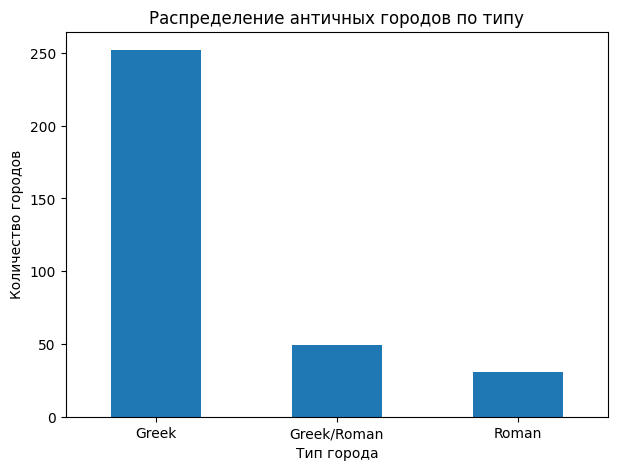


Больше всего в датасете памятников типа Greek: 252.
Значит, на территории современной Турции преобладает греческое историческое наследие.
Римские и смешанные греко-римские памятники тоже представлены, но их, как видно, кратно меньше.
При этом, количество тех и других приблизительно одинаковое.


In [ ]:
type_counts = df_clear['Type'].value_counts()

print('Количество городов каждого типа:')
print(type_counts)
print()

plt.figure(figsize=(7, 5))
type_counts.plot(kind='bar')
plt.title('Распределение античных городов по типу')
plt.xlabel('Тип города')
plt.ylabel('Количество городов')
plt.xticks(rotation=0)
plt.show()

main_type = type_counts.idxmax()
main_count = type_counts.max()


print(f'\nБольше всего в датасете памятников типа {main_type}: {main_count}.')
print('Значит, на территории современной Турции преобладает греческое историческое наследие.')
print('Римские и смешанные греко-римские памятники тоже представлены, но их, как видно, кратно меньше.\nПри этом, количество тех и других приблизительно одинаковое.')

**Создание простой карты для всех типов античных памятников**

Синим цветом на карте будут обозначены греческие памятники, фиолетовым - греко-римские, а красным - римские. Также будет добавлена всплывающая информация о памятнике при взаимодействии с объектом на карте, содержащая название, происхождение объекта, краткую справку о нем и ссылку на его страницу на портале Wikipedia.

In [ ]:
map_turkey = folium.Map(
    location=[39.0, 35.0],
    zoom_start=6,
    tiles='OpenStreetMap'
)

for index, row in df_clear.iterrows():

    if row['Type'] == 'Greek':
        color = '#1E90FF'
    elif row['Type'] == 'Roman':
        color = '#DC143C'
    elif row['Type'] == 'Greek/Roman':
        color = '#8A2BE2'
    else:
        color = '#FFFFFF'

    popup_text = f"""
    <b>{row['Name']}</b><br>
    Type: {row['Type']}<br><br>
    {row['Description']}<br><br>
    <a href="{row['Link']}" target="_blank">Source</a>
    """

    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['Name'],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 28px;
                color: {color};
                text-shadow: 0 0 8px {color};
            ">
                🏛
            </div>
            """
        )
    ).add_to(map_turkey)

sepia_style = """
<style>
.leaflet-tile {
    filter: sepia(75%) saturate(70%) brightness(95%) contrast(90%);
}
</style>
"""

map_turkey.get_root().html.add_child(folium.Element(sepia_style))

map_turkey

**Тепловая карта плотности объектов**

С помощью тепловой карты можно проследить зоны наибольшей концентрации памятников и увидеть, где находится больше всего античных объектов.

In [ ]:
import folium
from folium.plugins import HeatMap

heat_data = df_clear[['lat', 'lon']].values.tolist()

m_heat = folium.Map(
    location=[39.0, 35.0],
    zoom_start=6,
    tiles='OpenStreetMap'
)

HeatMap(heat_data, radius=15, blur=10).add_to(m_heat)

sepia_style = """
<style>
.leaflet-tile {
    filter: sepia(75%) saturate(70%) brightness(95%) contrast(90%);
}
</style>
"""

m_heat.get_root().html.add_child(folium.Element(sepia_style))

display(m_heat)

**Создание условных регионов современной Турции**

К уже имеющемуся у нас датасету мы добавляем новый столбец, который будет содержать информацию, в каком регионе на территории современной Турции расположен тот или иной памятник по долготе. Для большей наглядности создаем график с количественными данными.

In [62]:
def assign_region(lon):
    if pd.isna(lon):
        return None
    if lon < 30:
        return 'Западная Турция (Эгейско-Мраморская зона)'
    elif lon < 38:
        return 'Центральная и южная Анатолия'
    else:
        return 'Восточная и северо-восточная Анатолия'

df_clear['Region'] = df_clear['lon'].apply(assign_region)
df_clear = df_clear.dropna(subset=['Region'])

print(df_clear['Region'].value_counts())

Region
Западная Турция (Эгейско-Мраморская зона)    180
Центральная и южная Анатолия                 140
Восточная и северо-восточная Анатолия         12
Name: count, dtype: int64


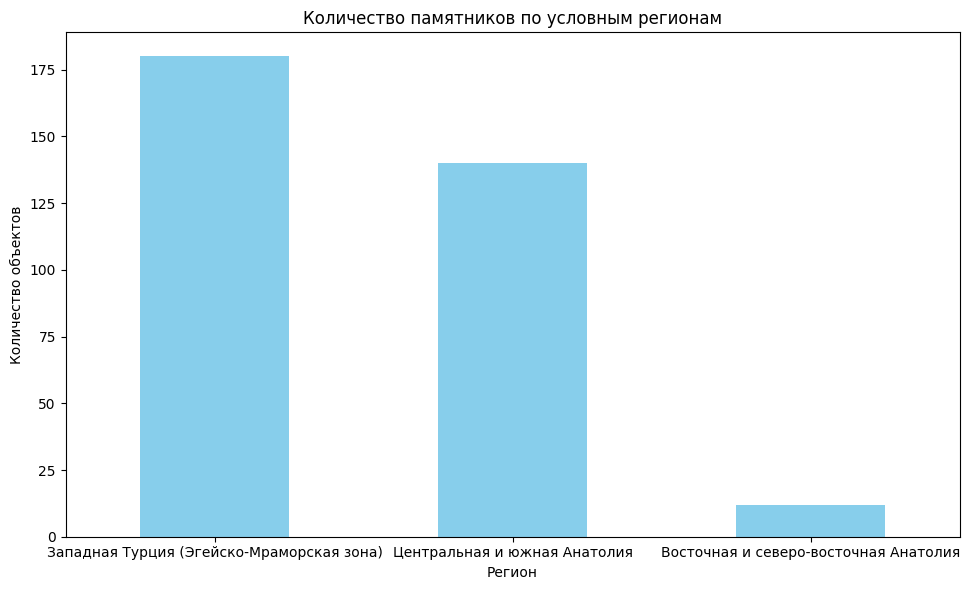


Превалирующий регион: Западная Турция (Эгейско-Мраморская зона) (180 объектов)


In [63]:
import matplotlib.pyplot as plt

region_counts = df['Region'].value_counts()
region_counts.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Количество памятников по условным регионам')
plt.xlabel('Регион')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dominant_region = region_counts.idxmax()
print(f'\nПревалирующий регион: {dominant_region} ({region_counts.max()} объектов)')

**Перекрёстная таблица: регион и тип объекта**

В этом блоке мы узнаем, какое именно происхождение памятников преобладает в каждом из регионов.

In [64]:
cross_tab = pd.crosstab(df['Region'], df['Type'])
display(cross_tab)

print('\nАналитика типов по регионам:')
for region in cross_tab.index:
    max_type = cross_tab.loc[region].idxmax()
    print(f'{region}: преобладает тип "{max_type}"')

Type,Greek,Greek/Roman,Roman
Region,,,
Восточная и северо-восточная Анатолия,9,3,0
Западная Турция (Эгейско-Мраморская зона),146,26,8
Центральная и южная Анатолия,97,20,23



Аналитика типов по регионам:
Восточная и северо-восточная Анатолия: преобладает тип "Greek"
Западная Турция (Эгейско-Мраморская зона): преобладает тип "Greek"
Центральная и южная Анатолия: преобладает тип "Greek"


**Итоговый вариант карты античных памятников**

Теперь карта содержит слои, отображающие все виды памятников по отдельности.

In [66]:
m_layers = folium.Map(
    location=[39.0, 35.0],
    zoom_start=6,
    tiles='OpenStreetMap'
)

layer_greek = folium.FeatureGroup(name='Greek')
layer_roman = folium.FeatureGroup(name='Roman')
layer_mixed = folium.FeatureGroup(name='Greek/Roman')

for index, row in df_clear.iterrows():

    if row['Type'] == 'Greek':
        color = '#1E90FF'
        layer = layer_greek
    elif row['Type'] == 'Roman':
        color = '#DC143C'
        layer = layer_roman
    elif row['Type'] == 'Greek/Roman':
        color = '#8A2BE2'
        layer = layer_mixed
    else:
        color = '#FFFFFF'
        layer = layer_greek

    popup_text = f"""
    <b>{row['Name']}</b><br>
    <b>Type:</b> {row['Type']}<br>
    <b>Region:</b> {row['Region']}<br><br>
    {row['Description']}<br><br>
    <a href="{row['Link']}" target="_blank">Source</a>
    """

    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['Name'],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 28px;
                color: {color};
                text-shadow: 0 0 8px {color};
            ">
                🏛
            </div>
            """
        )
    ).add_to(layer)

layer_greek.add_to(m_layers)
layer_roman.add_to(m_layers)
layer_mixed.add_to(m_layers)

folium.LayerControl().add_to(m_layers)

sepia_style = """
<style>
.leaflet-tile {
    filter: sepia(75%) saturate(70%) brightness(95%) contrast(90%);
}
</style>
"""

m_layers.get_root().html.add_child(folium.Element(sepia_style))

display(m_layers)

**Сохранение карты в HTML**

In [67]:
m_layers.save('antique_turkey_sites_map.html')
print('Карта успешно сохранена в файл "antique_turkey_sites_map.html"')

Карта успешно сохранена в файл "antique_turkey_sites_map.html"
